# 03: Structural metrics: Exact Match and Component F1

String-level comparison of generated vs gold query, no DB. Canonicalisation (comment-strip, alpha-rename of bindings, keyword upper-casing) lives in `eval_harness.canonical`, shared with notebook 04.

- **Exact Match (EM)**: equality of canonical strings.
- **Component F1**: per-clause F1 (node labels, edge types, directions, WHERE/RETURN/ORDER, LIMIT, aggregations), macro-averaged. Diagnostic for *where* the model fails.

An identity sanity test (gold vs itself -> EM=True, F1=1.0) runs first.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import pandas as pd
from eval_harness import load_records, load_dataset, OUTPUTS_DIR
from eval_harness.config import DATASETS_DIR
from eval_harness.canonical import exact_match, component_f1

OUT_CSV = OUTPUTS_DIR / 'metrics_structural.csv'

## Identity sanity test

Feed each gold query as its own translation; EM must be True and F1 = 1.0 for every target present in the datasets.

In [2]:
identity_rows = []
for ds_path in sorted(DATASETS_DIR.glob('*.yaml')):
    for q in load_dataset(ds_path.stem):
        for target, ref in q.expected.items():
            em = exact_match(ref, ref, target)
            cf = component_f1(ref, ref, target)['overall']
            identity_rows.append((ds_path.stem, q.id, target, em, cf))
identity_df = pd.DataFrame(identity_rows, columns=['dataset','query_id','target','em','component_f1'])
n_em = int((~identity_df['em']).sum()); n_cf = int((identity_df['component_f1'] < 0.999).sum())
print(f'Identity test: {len(identity_df)} cases; EM failures: {n_em}; F1<1.0: {n_cf}')
if n_em or n_cf:
    display(identity_df[(~identity_df['em']) | (identity_df['component_f1'] < 0.999)])
    raise AssertionError('Identity sanity test failed: canonicalisation has a bug.')
print('PASS')

Identity test: 56 cases; EM failures: 0; F1<1.0: 0
PASS


## Compute on the real records

Failed translations (null `generated_query`) get zeros so the report can tell 'failed to translate' from 'translated but wrong'.

In [3]:
records = load_records(OUTPUTS_DIR)
keys = ['dataset','target','model','query_id','difficulty']
rows = []
for r in records:
    translated = r.get('generated_query'); expected = r['expected_query']; target = r['target']
    base = {k: r[k] for k in keys}
    if not translated:
        rows.append({**base, 'exact_match': False, 'component_f1_overall': 0.0,
                     'f1_node_labels': 0.0, 'f1_edge_types': 0.0, 'f1_directions': 0.0,
                     'f1_where': 0.0, 'f1_return': 0.0, 'f1_order': 0.0, 'f1_limit': 0.0,
                     'f1_aggregations': 0.0})
        continue
    em = exact_match(translated, expected, target); cf = component_f1(translated, expected, target)
    rows.append({**base, 'exact_match': em, 'component_f1_overall': cf['overall'],
                 'f1_node_labels': cf['node_labels'], 'f1_edge_types': cf['edge_types'],
                 'f1_directions': cf['directions'], 'f1_where': cf['where'], 'f1_return': cf['return'],
                 'f1_order': cf['order'], 'f1_limit': cf['limit'], 'f1_aggregations': cf['aggregations']})
struct_df = pd.DataFrame(rows)
struct_df.head(8)

,dataset,target,model,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc,cypher,claude-opus-4-8,ldbc_q01,easy,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0
1,ldbc,cypher,claude-opus-4-8,ldbc_q02,easy,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0
2,ldbc,cypher,claude-opus-4-8,ldbc_q03,easy,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0
3,ldbc,cypher,claude-opus-4-8,ldbc_q04,hard,False,0.988636,1.0,1.0,1.0,1.000000,0.909091,1.0,1.0,1.0
4,ldbc,cypher,claude-opus-4-8,ldbc_q05,hard,False,0.838636,1.0,1.0,0.0,0.800000,0.909091,1.0,1.0,1.0
5,ldbc,cypher,claude-opus-4-8,ldbc_q06,medium,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0
6,ldbc,cypher,claude-opus-4-8,ldbc_q07,medium,False,0.926136,1.0,1.0,0.5,0.909091,1.000000,1.0,1.0,1.0
7,ldbc,cypher,claude-opus-4-8,ldbc_q08,hard,True,1.000000,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0


## Summaries

In [4]:
metric_cols = ['exact_match','component_f1_overall','f1_node_labels','f1_edge_types',
               'f1_directions','f1_where','f1_return','f1_order','f1_limit','f1_aggregations']
print('By dataset x target x model:')
display(struct_df.groupby(['dataset','target','model'])[metric_cols].mean())
print('By difficulty:')
display(struct_df.groupby('difficulty')[metric_cols].mean().reindex(['easy','medium','hard']))

By dataset x target x model:


exact_match  component_f1_overall  \
dataset target model                                                
ldbc    cypher claude-opus-4-8     0.500000              0.978990   
               gemma4:26b          0.642857              0.980154   
               llama3.2:latest     0.071429              0.816617   
               qwen3-coder:30b     0.285714              0.925995   

                                f1_node_labels  f1_edge_types  f1_directions  \
dataset target model                                                           
ldbc    cypher claude-opus-4-8        1.000000            1.0       0.875000   
               gemma4:26b             1.000000            1.0       0.875000   
               llama3.2:latest        0.757699            1.0       0.516667   
               qwen3-coder:30b        0.950000            1.0       0.767007   

                                f1_where  f1_return  f1_order  f1_limit  \
dataset target model                                                      
ldbc    cypher claude-opus-4-8  0.979221   0.977696  1.000000  1.000000   
               gemma4:26b       0.979221   0.987013  1.000000  1.000000   
               llama3.2:latest  0.514103   0.877797  0.961905  0.928571   
               qwen3-coder:30b  0.764935   0.926015  1.000000  1.000000   

                                f1_aggregations  
dataset target model                             
ldbc    cypher claude-opus-4-8          1.00000  
               gemma4:26b               1.00000  
               llama3.2:latest          0.97619  
               qwen3-coder:30b          1.00000

By difficulty:


,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
difficulty,,,,,,,,,,
easy,0.833333,0.956282,0.944444,1.0,0.833333,0.886364,0.986111,1.000000,1.000000,1.000000
medium,0.125000,0.925783,0.905032,1.0,0.764583,0.833498,0.923982,0.979167,1.000000,1.000000
hard,0.321429,0.912024,0.931926,1.0,0.722789,0.762585,0.933652,0.992857,0.964286,0.988095


In [5]:
struct_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(struct_df)} rows to {OUT_CSV}')

Wrote 56 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_structural.csv


## Visualizations: structural quality across models / queries

Where each model is weak (per-clause F1), the per-query F1 matrix, and per-model exact match / component F1. Grey `n/a` cells mark a model with no structural row yet (partial run).

In [6]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS = plots.model_axis(struct_df); QUERIES = plots.query_axis(struct_df)
print(f'{len(MODELS)} model(s): {MODELS}')

4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


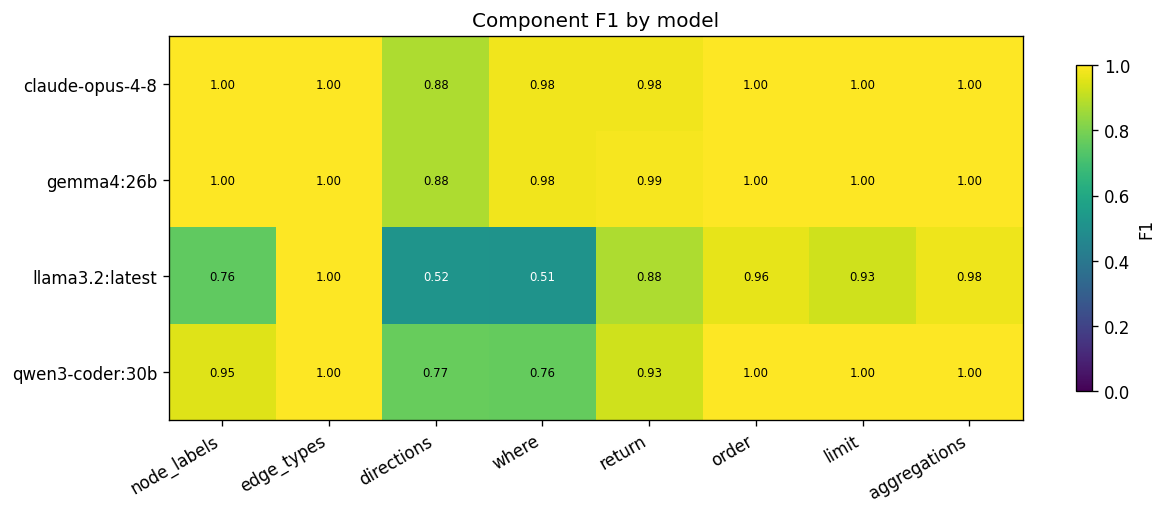

In [7]:
# Where each model is weak: mean per-clause F1, one row per model.
p = FIG_DIR / 'component_f1.png'
plots.component_f1_by_model(struct_df, path=p)
plots.show(p)

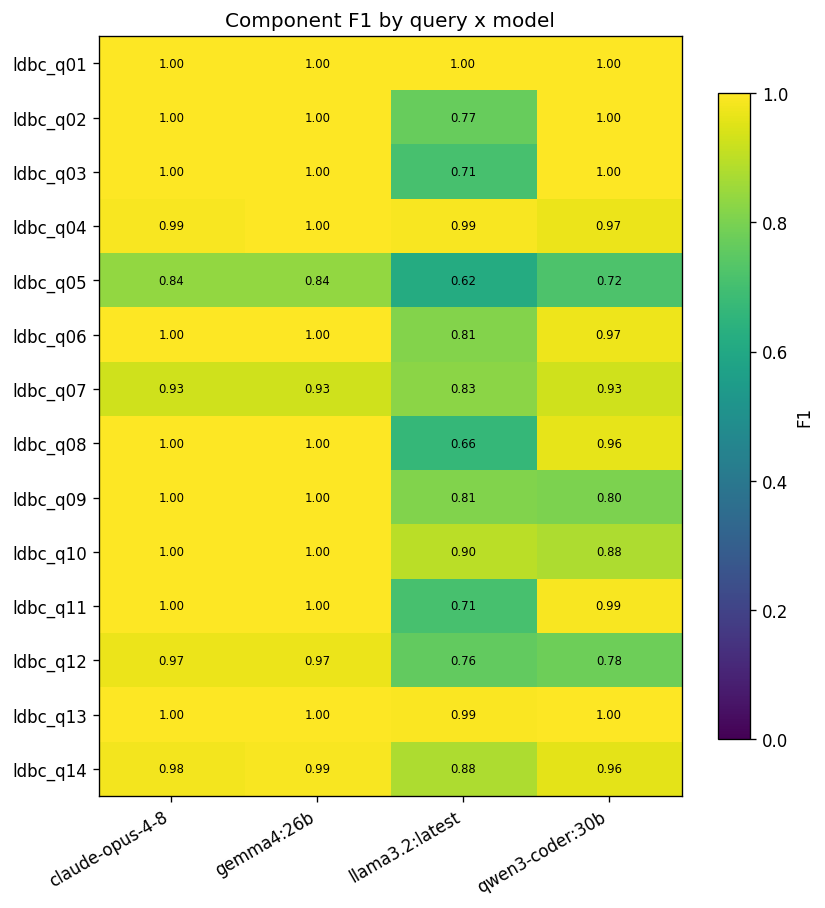

In [8]:
# Per-query structural quality across models (grey n/a where a model has no structural row).
p = FIG_DIR / 'query_model_f1.png'
plots.query_model_heatmap(struct_df, 'component_f1_overall', p, models=MODELS, queries=QUERIES,
                          title='Component F1 by query x model', cbar_label='F1')
plots.show(p)

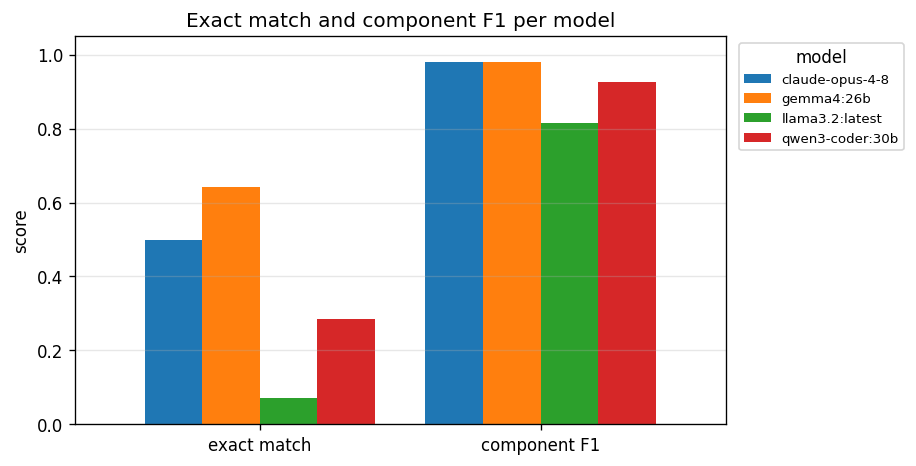

In [9]:
# Per-model exact match and overall component F1.
p = FIG_DIR / 'structural_bars.png'
plots.per_model_bars(struct_df, ['exact_match', 'component_f1_overall'], p,
                     title='Exact match and component F1 per model', ylabel='score',
                     labels={'exact_match': 'exact match', 'component_f1_overall': 'component F1'})
plots.show(p)